In [1]:
# In your new notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Load the trades from your backtest
trades = pd.read_csv('../data/processed/backtest_trades_paper_v3_final.csv')

# Get the list of individual returns for each trade
# The 'Return Pct' is the profit/loss as a percentage. We add 1 for cumulative calculation.
trade_returns = trades['ReturnPct'] + 1

In [2]:
n_simulations = 10000
n_trades = len(trade_returns)
starting_equity = 10000

# We will now store the Max Drawdown for each random simulation
simulated_max_drawdowns = []

for i in range(n_simulations):
    # Shuffle the order of our real trade returns randomly
    shuffled_returns = np.random.permutation(trade_returns.values)
    
    # Calculate the full equity curve for this random sequence
    equity_curve = np.cumprod(shuffled_returns) * starting_equity
    
    # Calculate the running maximum of the equity curve
    running_max = np.maximum.accumulate(equity_curve)
    
    # Calculate the drawdown series
    drawdown = (equity_curve - running_max) / running_max
    
    # Store the absolute maximum drawdown for this simulation
    simulated_max_drawdowns.append(abs(drawdown.min()))

print(f"Simulation complete. Calculated Max Drawdown for {n_simulations} random scenarios.")

Simulation complete. Calculated Max Drawdown for 10000 random scenarios.


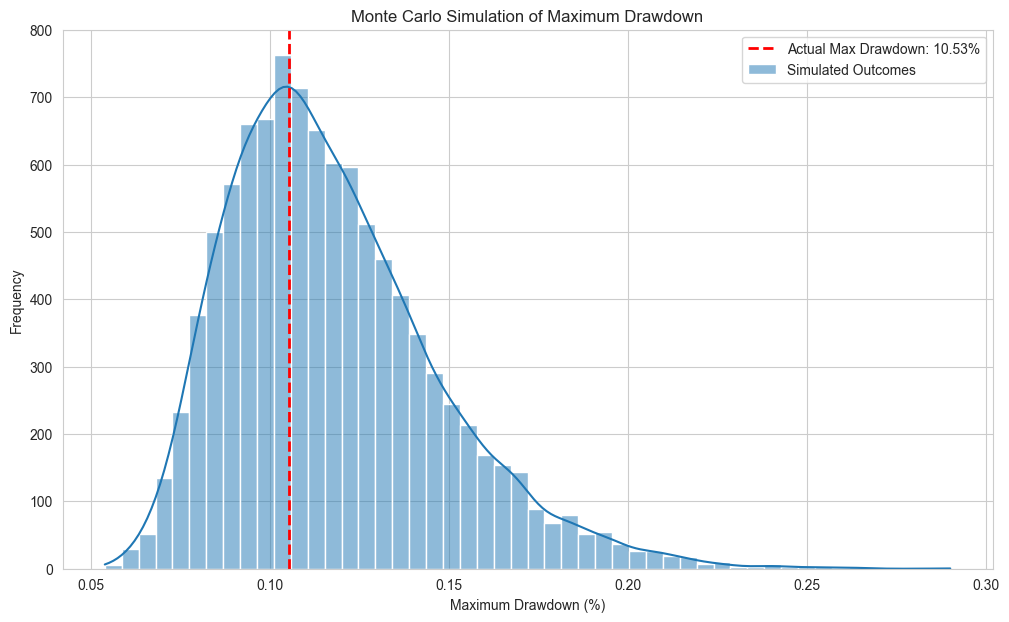

Actual Max Drawdown: 10.53%
Average Max Drawdown in Random Simulations: 11.74%
Probability of a random shuffle having a better (lower) drawdown: 39.04%


In [3]:
# First, calculate the Max Drawdown of our ACTUAL (unshuffled) strategy
actual_equity_curve = np.cumprod(trade_returns.values) * starting_equity
actual_running_max = np.maximum.accumulate(actual_equity_curve)
actual_drawdown = (actual_equity_curve - actual_running_max) / actual_running_max
actual_max_drawdown = abs(actual_drawdown.min())

# Plot the distribution of random drawdowns
plt.figure(figsize=(12, 7))
sns.histplot(simulated_max_drawdowns, kde=True, bins=50, label='Simulated Outcomes')

# Add a vertical line showing our ACTUAL strategy's drawdown
plt.axvline(x=actual_max_drawdown, color='red', linestyle='--', linewidth=2, 
            label=f'Actual Max Drawdown: {actual_max_drawdown:.2%}')

plt.title(f'Monte Carlo Simulation of Maximum Drawdown')
plt.xlabel('Maximum Drawdown (%)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Calculate the p-value (how many random runs had a BETTER (smaller) drawdown?)
p_value_drawdown = np.sum(np.array(simulated_max_drawdowns) < actual_max_drawdown) / n_simulations

print(f"Actual Max Drawdown: {actual_max_drawdown:.2%}")
print(f"Average Max Drawdown in Random Simulations: {np.mean(simulated_max_drawdowns):.2%}")
print(f"Probability of a random shuffle having a better (lower) drawdown: {p_value_drawdown:.2%}")

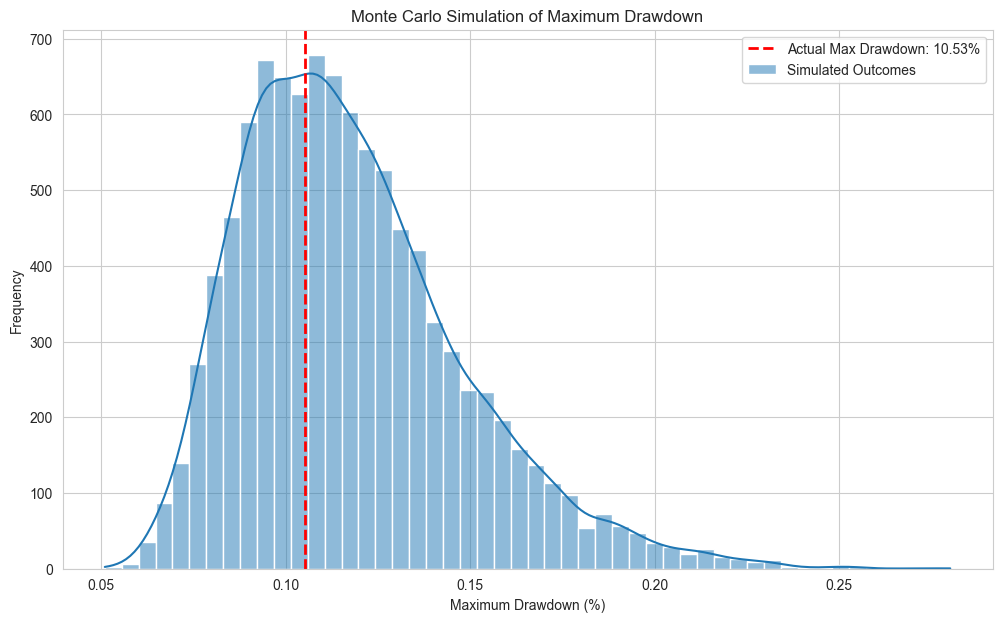

Actual Max Drawdown: 10.53%
Average Max Drawdown in Random Simulations: 11.79%
Probability of a random shuffle having a better (lower) drawdown: 38.29%


In [13]:
# First, calculate the Max Drawdown of our ACTUAL (unshuffled) strategy
actual_equity_curve = np.cumprod(trade_returns.values) * starting_equity
actual_running_max = np.maximum.accumulate(actual_equity_curve)
actual_drawdown = (actual_equity_curve - actual_running_max) / actual_running_max
actual_max_drawdown = abs(actual_drawdown.min())

# Plot the distribution of random drawdowns
plt.figure(figsize=(12, 7))
sns.histplot(simulated_max_drawdowns, kde=True, bins=50, label='Simulated Outcomes')

# Add a vertical line showing our ACTUAL strategy's drawdown
plt.axvline(x=actual_max_drawdown, color='red', linestyle='--', linewidth=2, 
            label=f'Actual Max Drawdown: {actual_max_drawdown:.2%}')

plt.title(f'Monte Carlo Simulation of Maximum Drawdown')
plt.xlabel('Maximum Drawdown (%)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Calculate the p-value (how many random runs had a BETTER (smaller) drawdown?)
p_value_drawdown = np.sum(np.array(simulated_max_drawdowns) < actual_max_drawdown) / n_simulations

print(f"Actual Max Drawdown: {actual_max_drawdown:.2%}")
print(f"Average Max Drawdown in Random Simulations: {np.mean(simulated_max_drawdowns):.2%}")
print(f"Probability of a random shuffle having a better (lower) drawdown: {p_value_drawdown:.2%}")